# Detection of Covid-19 from Chest-X-ray

In [1]:
# Import the required modules
!pip install keras_preprocessing
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.6 MB/s eta 0:00:00


In [2]:
# pip install keras_preprocessing

# Data ingesting of Covid 19 images

# Method No 3: Data ingest using Direct method

In [3]:
BASIS_DIR = '/content/sample_data/imaagedataset'
CLASSES = ["femaleeyes",  "maleeyes"]

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range = 0.2,
    zoom_range = 0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode = 'nearest',

    #split dataset to training(80%) and validation(20%):
    validation_split=0.2
)

# Training dataset and Validation dataset:

In [16]:
train_data = train_datagen.flow_from_directory(
    BASIS_DIR,
    target_size=(299,299),
    batch_size=2,
    subset='training',
    class_mode='binary',
    classes=CLASSES
)


Found 4 images belonging to 2 classes.


In [19]:
train_data = train_datagen.flow_from_directory(
    directory=BASIS_DIR,
    target_size=(299,299),
    batch_size=4,
    shuffle=True,
    class_mode='binary',
    classes=CLASSES
)

Found 4 images belonging to 2 classes.


# Using sequential model:

In [20]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(299, 299, 3)), # Use Input layer instead of input_shape
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,057 (16.39 MB)

 Trainable params: 4,297,057 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# (filter_height*filter_width*number_of_channels+1)*number_of_filters
(3*3*32+1)*32

9248

In [23]:
# Compiling model with 'adam' optimizer loss function 'binary_crossentropy'
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy']
             )

In [24]:
# Training process:
number_epochs = 3
# You can change number_epochs above. But the bigger the value, the more time it takes for training
history = model.fit(train_data, epochs=number_epochs, verbose=2)


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 - 3s - 3s/step - accuracy: 0.5000 - loss: 0.6971
Epoch 2/3
1/1 - 1s - 633ms/step - accuracy: 0.5000 - loss: 0.8131
Epoch 3/3
1/1 - 1s - 650ms/step - accuracy: 0.5000 - loss: 0.7942


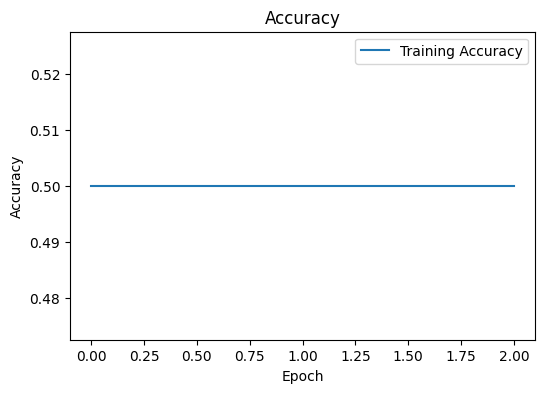

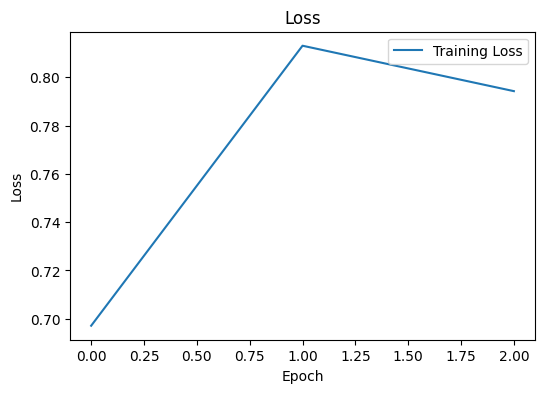

In [26]:
# Plotting training accuracy and validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')

if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

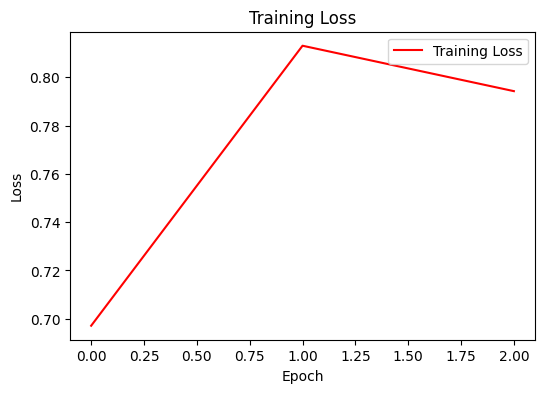

In [28]:
# Plotting training loss and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], 'r', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
import tensorflow as tf
from tensorflow.keras.models import save_model
# Save the compiled model to an H5 file
save_model(model, 'model.h5')

# Test random image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
COVID


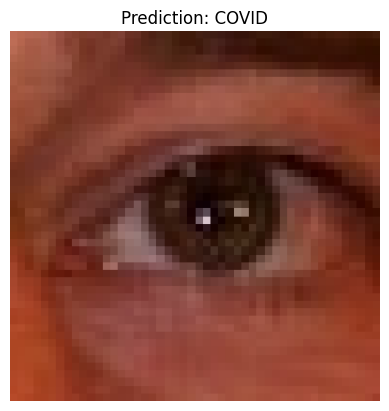

In [31]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Assuming you have a pre-trained model saved as 'your_model.h5'
model = load_model('model.h5')

path = "/content/sample_data/imaagedataset/maleeyes/1.jpg"
img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

# Assuming your model output has two classes (COVID and Normal)
threshold = 0.5
prediction = "COVID" if result[0][0] > threshold else "NORMAL"
print(prediction)

# Display the image
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis('off')  # Hide the axes
plt.show()
